In [1]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Settings
random.seed(42)
n_logs = 5000

# Sample data
ips = ['192.168.1.'+str(i) for i in range(1, 50)] + ['10.0.0.'+str(i) for i in range(1, 20)]
suspicious_ips = ['45.33.32.156', '198.20.69.74', '89.248.167.131', '185.220.101.45']
usernames = ['admin', 'root', 'user1', 'john', 'sarah', 'guest', 'administrator']
statuses = ['SUCCESS', 'FAILED', 'FAILED', 'FAILED']  # weighted toward FAILED

logs = []
base_time = datetime(2024, 1, 1)

for i in range(n_logs):
    ip = random.choice(ips + suspicious_ips)
    timestamp = base_time + timedelta(minutes=random.randint(0, 43200))
    status = random.choice(statuses)
    username = random.choice(usernames)
    logs.append({'timestamp': timestamp, 'ip_address': ip, 'username': username, 'status': status})

df = pd.DataFrame(logs)
df = df.sort_values('timestamp').reset_index(drop=True)
df.to_csv('../data/server_logs.csv', index=False)
print(f"Generated {len(df)} log entries")
print(df.head(10))

Generated 5000 log entries
            timestamp      ip_address       username   status
0 2024-01-01 00:06:00    192.168.1.36          guest   FAILED
1 2024-01-01 00:06:00     192.168.1.2          user1   FAILED
2 2024-01-01 00:11:00  89.248.167.131  administrator  SUCCESS
3 2024-01-01 00:17:00    192.168.1.14          sarah  SUCCESS
4 2024-01-01 00:23:00    192.168.1.39          user1  SUCCESS
5 2024-01-01 00:35:00    192.168.1.22           john  SUCCESS
6 2024-01-01 00:42:00       10.0.0.19          guest   FAILED
7 2024-01-01 00:42:00    192.168.1.46          user1  SUCCESS
8 2024-01-01 01:04:00    192.168.1.29          guest  SUCCESS
9 2024-01-01 01:23:00    192.168.1.14           john  SUCCESS


In [2]:
# Load logs
df = pd.read_csv('../data/server_logs.csv')

# Count failed logins per IP
failed = df[df['status'] == 'FAILED']
failed_by_ip = failed.groupby('ip_address').size().reset_index(name='failed_attempts')
failed_by_ip = failed_by_ip.sort_values('failed_attempts', ascending=False)

print("Top 10 IPs with most failed logins:")
print(failed_by_ip.head(10))

Top 10 IPs with most failed logins:
      ip_address  failed_attempts
17      10.0.0.8               69
12      10.0.0.3               65
69  198.20.69.74               65
34  192.168.1.22               64
38  192.168.1.26               64
62  192.168.1.48               62
52  192.168.1.39               61
15      10.0.0.6               61
50  192.168.1.37               60
56  192.168.1.42               60


In [3]:
# Anyone with more than 50 failed attempts = suspicious
brute_force = failed_by_ip[failed_by_ip['failed_attempts'] > 50]
brute_force['threat_level'] = 'HIGH'

print(f"Suspicious IPs detected: {len(brute_force)}")
print(brute_force)

# Save report
brute_force.to_csv('../reports/suspicious_ips.csv', index=False)
print("\nReport saved!")

Suspicious IPs detected: 38
        ip_address  failed_attempts threat_level
17        10.0.0.8               69         HIGH
12        10.0.0.3               65         HIGH
69    198.20.69.74               65         HIGH
34    192.168.1.22               64         HIGH
38    192.168.1.26               64         HIGH
62    192.168.1.48               62         HIGH
52    192.168.1.39               61         HIGH
15        10.0.0.6               61         HIGH
50    192.168.1.37               60         HIGH
56    192.168.1.42               60         HIGH
5        10.0.0.14               60         HIGH
63    192.168.1.49               59         HIGH
37    192.168.1.25               58         HIGH
32    192.168.1.20               58         HIGH
3        10.0.0.12               58         HIGH
30    192.168.1.19               58         HIGH
41    192.168.1.29               57         HIGH
4        10.0.0.13               57         HIGH
16        10.0.0.7               57      

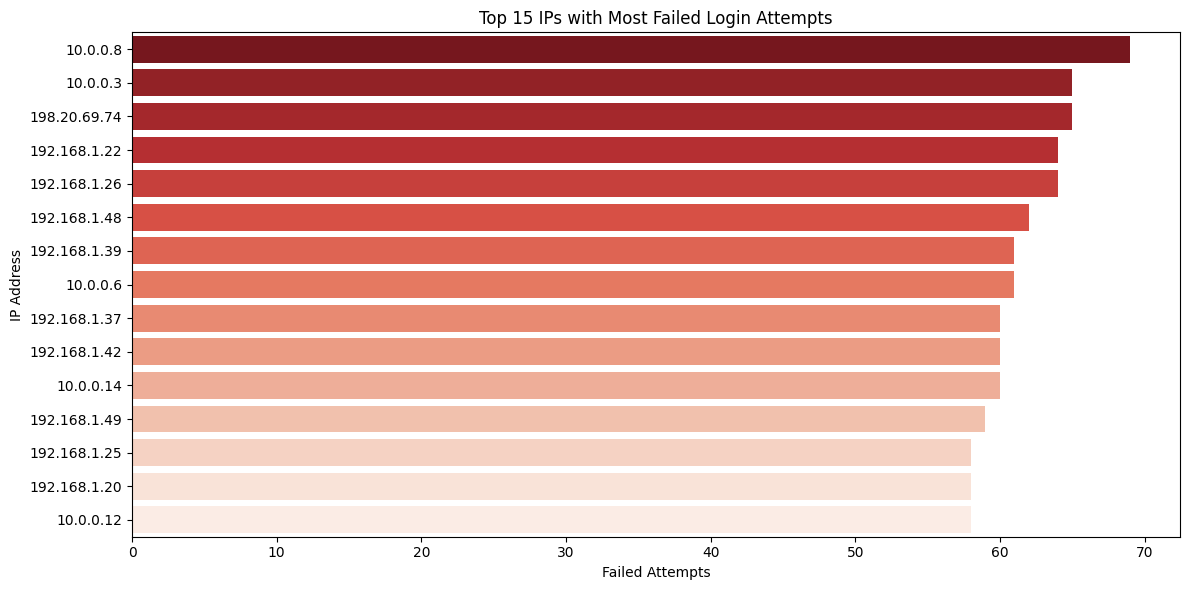

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 most suspicious IPs
top15 = failed_by_ip.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top15, x='failed_attempts', y='ip_address', 
            hue='ip_address', palette='Reds_r', legend=False)
plt.title('Top 15 IPs with Most Failed Login Attempts')
plt.xlabel('Failed Attempts')
plt.ylabel('IP Address')
plt.tight_layout()
plt.savefig('../screenshots/failed_logins_by_ip.png')
plt.show()

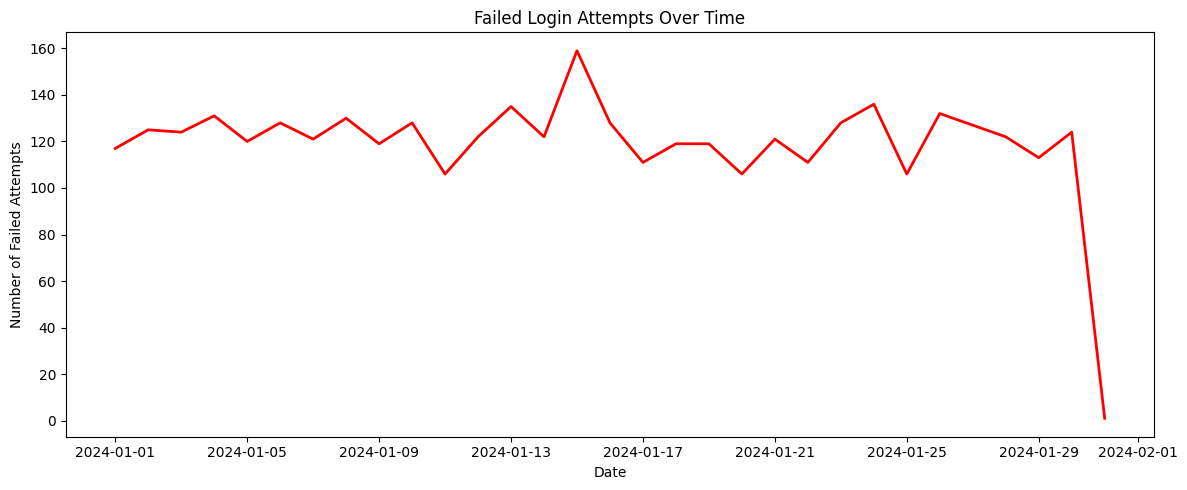

In [5]:
# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Failed logins per day
failed_over_time = df[df['status'] == 'FAILED'].copy()
failed_over_time['date'] = failed_over_time['timestamp'].dt.date
daily_failed = failed_over_time.groupby('date').size()

plt.figure(figsize=(12, 5))
daily_failed.plot(kind='line', color='red', linewidth=2)
plt.title('Failed Login Attempts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Failed Attempts')
plt.tight_layout()
plt.savefig('../screenshots/failed_logins_over_time.png')
plt.show()

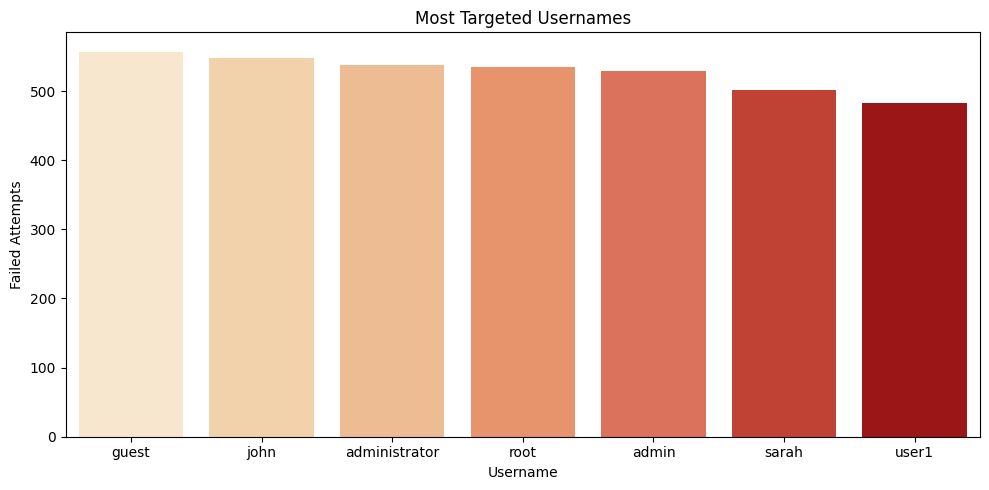

In [6]:
# Which usernames are being targeted most
failed_by_user = failed.groupby('username').size().reset_index(name='failed_attempts')
failed_by_user = failed_by_user.sort_values('failed_attempts', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=failed_by_user, x='username', y='failed_attempts',
            hue='username', palette='OrRd', legend=False)
plt.title('Most Targeted Usernames')
plt.xlabel('Username')
plt.ylabel('Failed Attempts')
plt.tight_layout()
plt.savefig('../screenshots/targeted_usernames.png')
plt.show()

In [7]:
# Merge failed attempts with threat level
df_report = df.merge(failed_by_ip, on='ip_address', how='left')
df_report['threat_level'] = df_report['failed_attempts'].apply(
    lambda x: 'HIGH' if x > 50 else ('MEDIUM' if x > 30 else 'LOW')
)

# Save full report
df_report.to_csv('../reports/full_threat_report.csv', index=False)
print("Full threat report saved!")
print(df_report['threat_level'].value_counts())

Full threat report saved!
threat_level
HIGH      2870
MEDIUM    2130
Name: count, dtype: int64


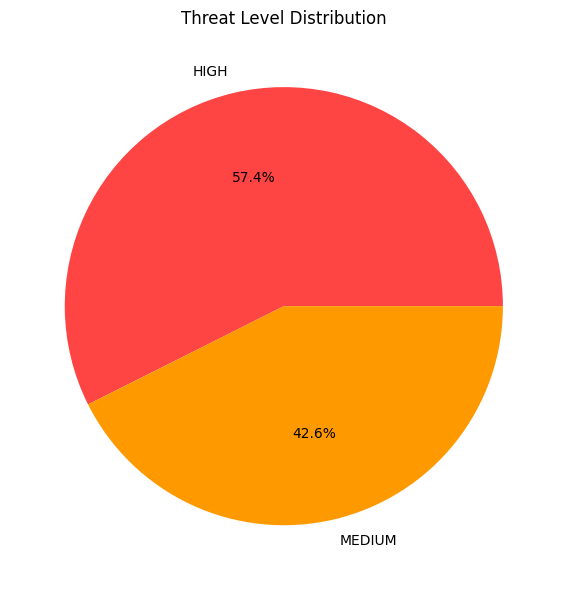

In [8]:
threat_counts = df_report['threat_level'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(threat_counts, labels=threat_counts.index, autopct='%1.1f%%', 
        colors=['#ff4444', '#ff9900', '#00cc44'])
plt.title('Threat Level Distribution')
plt.tight_layout()
plt.savefig('../screenshots/threat_levels.png')
plt.show()